<a href="https://colab.research.google.com/github/Aymon05/Deep-learning-projects/blob/main/101Food.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiclass Classification
These model will detect 10 different kinds of food

# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import zipfile

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Get data

In [ ]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2026-09-01 17:02:56--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.75.207, 192.178.164.207, 192.178.231.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.75.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  97.5MB/s    in 4.8s    

2026-09-01 17:03:01 (103 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [ ]:
zip_ref = zipfile.ZipFile('/content/10_food_classes_all_data.zip')
zip_ref.extractall()
zip_ref.close()

In [ ]:
class_names = os.listdir('/content/10_food_classes_all_data/train')

In [ ]:
len(os.listdir('/content/10_food_classes_all_data/train/fried_rice'))

750

In [ ]:
# Set up train and test directories
train_dir = '/content/10_food_classes_all_data/train'
test_dir = '/content/10_food_classes_all_data/test'

# Visualize data
Make a function

In [ ]:
import random
def view_images(path,classes = class_names):
    class_name = random.choice(classes)
    file_path = path + '/' + class_name
    img_list = os.listdir(file_path)
    img_path = file_path + '/' + random.choice(img_list)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(class_name)


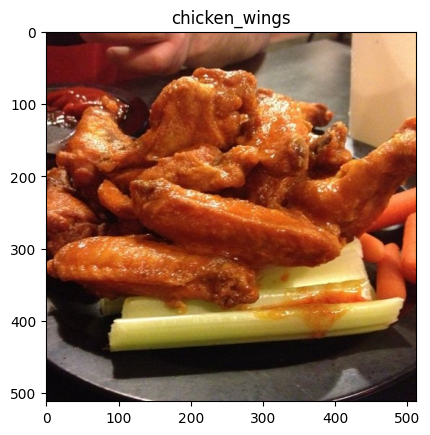

In [ ]:
view_images(train_dir)

# Preprocess data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1./255,rotation_range = 0.2,width_shift_range = 0.2,
                                   height_shift_range = 0.2,horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(train_dir,batch_size = 32,target_size = (224,224),class_mode = 'categorical',
                                               shuffle = True)
test_data = test_datagen.flow_from_directory(test_dir,batch_size = 32,target_size = (224,224),class_mode = 'categorical',
                                             shuffle = True)

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


# Create a model

In [ ]:
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPool2D
from tensorflow.keras import Sequential
from keras.losses import CategoricalCrossentropy
from keras.optimizers import Adam

In [ ]:
model_1 = Sequential([
    Conv2D(filters = 10,kernel_size = 3,input_shape = (224,224,3),activation = 'relu',padding = 'valid'),
    Conv2D(filters = 10,kernel_size = 3,input_shape = (224,224,3),activation = 'relu',padding = 'valid'),
    MaxPool2D(pool_size = 2,padding = 'valid'),
    Conv2D(filters = 10,kernel_size = 3,input_shape = (224,224,3),activation = 'relu',padding = 'valid'),
    Conv2D(filters = 10,kernel_size = 3,input_shape = (224,224,3),activation = 'relu',padding = 'valid'),
    MaxPool2D(pool_size = 2,padding = 'valid'),
    Flatten(),
    Dense(10,activation = 'softmax')
])
model_1.compile(loss = CategoricalCrossentropy(),
                optimizer = Adam(),
                metrics = ['accuracy'])
history_1 = model_1.fit(train_data,epochs = 10,steps_per_epoch = len(train_data),
                        validation_data = test_data,validation_steps = len(test_data))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 109s 451ms/step - accuracy: 0.1468 - loss: 2.2469 - val_accuracy: 0.1988 - val_loss: 2.1460
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 102s 432ms/step - accuracy: 0.2221 - loss: 2.1416 - val_accuracy: 0.2896 - val_loss: 2.0154
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 105s 444ms/step - accuracy: 0.2795 - loss: 2.0418 - val_accuracy: 0.3300 - val_loss: 1.8925
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 103s 437ms/step - accuracy: 0.3004 - loss: 1.9971 - val_accuracy: 0.3464 - val_loss: 1.8895
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 102s 434ms/step - accuracy: 0.3103 - loss: 1.9547 - val_accuracy: 0.3820 - val_loss: 1.7832
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 102s 434ms/step - accuracy: 0.3292 - loss: 1.9294 - val_accuracy: 0.3720 - val_loss: 1.8308
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 104s 442ms/step - accuracy: 0.3396 - loss: 1.9087 - val_accuracy: 0.3992 - val_loss: 1.7632
Epoch 8/10
 44/235 ━━━━━━━━━━━━━━━━━━━━ 1:19 417ms/step - accuracy: 0.3641 -

KeyboardInterrupt: 

# Evaluate the model

In [ ]:
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.4144 - loss: 1.6938


[1.6937543153762817, 0.41440001130104065]

In [ ]:
def plot_loss_curve(history):
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(accuracy))
    plt.figure(figsize = (10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs,accuracy,label = 'Training accuracy')
    plt.plot(epochs,val_accuracy,label = 'Test accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.figure(figsize = (10,4))
    plt.subplot(1,2,2)
    plt.plot(epochs,loss,label = 'Training loss')
    plt.plot(epochs,val_loss,label = 'Test loss')
    plt.title('Loss curve')
    plt.legend()


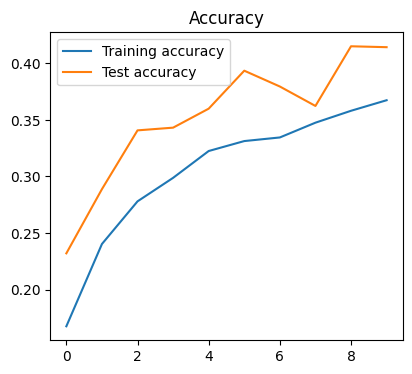

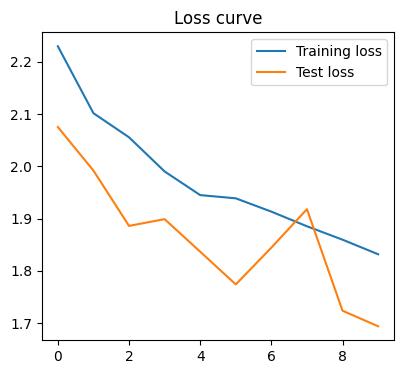

In [ ]:
plot_loss_curve(history_1)

In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)

# Save and load the model

In [ ]:
model_1.save('my_model_1.keras')

TypeError: CategoricalCrossentropy.get_config() missing 1 required positional argument: 'self'

In [ ]:
loaded_model = tf.keras.models.load_model('my_model_1.keras')

ValueError: File not found: filepath=my_model_1.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
loaded_model.evaluate(test_data)

NameError: name 'loaded_model' is not defined